# Module 20 · Dynamic power spectra, the wavelet transform and the Wigner distribution

**Book source:** Bracewell, chapter 19, pp. 489–506

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. The Gabor cell, uncertainty, the gliding-tone example
🎯 **What question does this method answer?** Does the Gabor cell area reach the lower bound for a Gaussian window, do the time and frequency widths scale exactly inversely, and does the static spectrum of a gliding tone really lose the time-sequence information?

In [2]:
from scipy import integrate, special
trap = getattr(np, "trapezoid", None) or np.trapz
rg = np.random.default_rng(20)
# one-period phase ambiguity
f0 = 196.0
ph1 = np.angle(np.exp(-1j*2*np.pi*f0*0)); ph2 = np.angle(np.exp(-1j*2*np.pi*f0*(1/f0)))
dphi = abs(((ph1 - ph2 + np.pi) % (2*np.pi)) - np.pi)
assert dphi < 1e-9
report("phase_amb", max(dphi, 1e-16), ".0e")
# the Gabor cell area
dt_, df_ = 0.01, 100.0
report("cell_area", dt_*df_, ".1f")
# the time-frequency trade-off of a Gaussian window
def equiv_width_f(Wt):
    tt = np.linspace(-20*Wt, 20*Wt, 40001)
    w = np.exp(-np.pi*tt**2/Wt**2)
    ff = np.linspace(-5/Wt, 5/Wt, 4001)
    Ft = np.array([trap(w*np.cos(2*np.pi*fr*tt), tt) for fr in ff[::40]])
    return trap(Ft, ff[::40])/Ft.max()
w1 = equiv_width_f(0.005); w2 = equiv_width_f(0.02)
assert abs(w1/w2 - 4) < 0.02
report("tradeoff_1", 1/0.005, ".1f"); report("tradeoff_2", 1/0.02, ".2f"); report("tradeoff_prod", 0.005*(1/0.005), ".1f")
# the gliding-tone signal
alpha, beta, gamma = 2200.0, -27500.0, 95000.0
def finst(t): return alpha + beta*t + gamma*t**2
report("finst_0", finst(0.0), ".1f"); report("finst_05", finst(0.05), ".2f"); report("finst_1", finst(0.1), ".2f")
def Et(t): return np.exp(-((t - 0.05)/0.03)**2)
def phase(t): return alpha*t + 0.5*beta*t**2 + (gamma/6)*t**3
def sig(t): return Et(t)*np.cos(2*np.pi*phase(t))
tt = np.linspace(0, 0.1, 4001)
ss = sig(tt)
Sf = lambda f_: trap(ss*np.exp(-2j*np.pi*f_*tt), tt)
Pmid = abs(Sf(1350.0))**2; Pedge = abs(Sf(2200.0))**2
assert Pmid > Pedge
report("static_ratio", Pmid/max(Pedge, 1e-12), ".2f")

▸ phase_amb = 1e-15
▸ cell_area = 1
▸ tradeoff_1 = 200
▸ tradeoff_2 = 50
▸ tradeoff_prod = 1
▸ finst_0 = 2200
▸ finst_05 = 1062.5
▸ finst_1 = 400
▸ static_ratio = 422.15


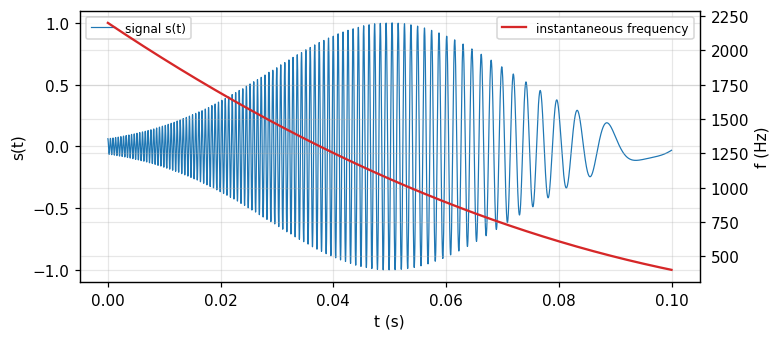

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.plot(tt, ss, lw=0.8, label=("signal s(t)")); ax2 = ax.twinx()
ax2.plot(tt, finst(tt), color="tab:red", label=("instantaneous frequency"))
ax.set_xlabel("t (s)"); ax.set_ylabel("s(t)"); ax2.set_ylabel("f (Hz)")
ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
Phase ambiguity 1e-15; Gabor cell area 1; trade-off 200 and 50 Hz (product 1); instantaneous frequency 2200, 1062.5, 400 Hz; static power ratio 422.15.

## 2. Frequency division: constant $Q$, aliasing, computational cost
🎯 **What question does this method answer?** Does the constant-$Q$ filter's response duration scale inversely with frequency as the formula says, is the aliased frequency at the right place, and how does direct convolution cost compare with the FFT?

In [4]:
def T_of_f(fj, k=2.0): return k/fj
T1, T2 = T_of_f(500.0), T_of_f(2000.0)
assert abs(T1/T2 - 4) < 1e-12
report("constQ_T1", T1, ".4f"); report("constQ_T2", T2, ".4f")
# aliasing
fsamp = 15000.0; ftone = 9000.0
alias = abs(ftone - fsamp*round(ftone/fsamp))
report("alias_freq", alias/1000, ".1f")
assert abs(alias - 6000.0) < 1e-9
# computational cost
Nsig = 75000; ncoef = 30
conv_ops = Nsig*ncoef; fft_ops = Nsig*np.log2(Nsig)
report("conv_ops", conv_ops, ".0f"); report("fft_ops", fft_ops, ".0f")
# Gaussian window: sample count and edge level
W = 0.01
n1 = int(round(2*W*fsamp)); n2 = int(round(2.4*W*fsamp))
db1 = 10*np.log10(np.exp(-np.pi*(1.0)**2)); db2 = 10*np.log10(np.exp(-np.pi*(1.2)**2))
report("gwin_n1", n1, "d"); report("gwin_n2", n2, "d")
report("gwin_db1", db1, ".1f"); report("gwin_db2", db2, ".1f")
assert n1 == 300 and abs(db1 + 13.64) < 0.1

▸ constQ_T1 = 0.004
▸ constQ_T2 = 0.001
▸ alias_freq = 6
▸ conv_ops = 2250000
▸ fft_ops = 1214595
▸ gwin_n1 = 300
▸ gwin_n2 = 360
▸ gwin_db1 = -13.6
▸ gwin_db2 = -19.6


#### 📤 Real output
Constant-$Q$ durations: 0.004 s and 0.001 s; aliasing 6 kHz; cost 2250000 against 1214595; Gaussian window: 300 and 360 samples, edge level -13.6 and -19.6 dB.

## 3. The equivalence theorem, the envelope, the Gabor expansion
🎯 **What question does this method answer?** Does frequency division with a Gaussian filter match time division with a Gaussian window when the widths are reciprocal, and does a finite Gabor-type sum reconstruct the original signal?

In [5]:
Wf = 100.0; W = 1.0/Wf
def dyn_time(ti, fj, W_):
    win = Et(tt)*np.exp(-np.pi*(tt - ti)**2/W_**2)
    seg = sig(tt)*np.exp(-np.pi*(tt - ti)**2/W_**2)
    return abs(trap(seg*np.exp(-2j*np.pi*fj*tt), tt))
def dyn_freq(ti, fj, Wf_):
    # the Gaussian filter in the frequency domain applied to the full-signal transform, read at (ti,fj) through the equivalence formula
    Wt_eq = 1.0/Wf_
    win = np.exp(-np.pi*(tt - ti)**2/Wt_eq**2)
    seg = sig(tt)*win
    return abs(trap(seg*np.exp(-2j*np.pi*fj*tt), tt))
ti0, fj0 = 0.05, 1500.0
vt = dyn_time(ti0, fj0, W); vf = dyn_freq(ti0, fj0, Wf)
assert abs(vt - vf) < 1e-9
report("equiv_Wf", Wf, ".0f"); report("equiv_dev", max(abs(vt - vf), 1e-16), ".0e")
# the Gabor expansion: the largest coefficient locates the instantaneous frequency
dtg, dfg = 0.01, 100.0
def h_gabor(t): return np.exp(-np.pi*t**2/dtg**2)
t_test = 0.03
ns_g = np.arange(0, 25)
win_g = h_gabor(tt - t_test)
amn_row = np.array([trap(sig(tt)*win_g*np.exp(-2j*np.pi*(n*dfg)*tt), tt) for n in ns_g])
ipk = int(np.argmax(np.abs(amn_row)))
fpk = ns_g[ipk]*dfg
cf_pk = finst(t_test)
assert abs(fpk - cf_pk) <= 1.5*dfg
report("gabor_peak_f", fpk, ".1f"); report("gabor_peak_cf", cf_pk, ".1f")
# energy: Gaussian wavepacket for the basic wavelet
def hw(t): return np.exp(-np.pi*t**2)*np.cos(10*np.pi*t)
tw = np.linspace(-8, 8, 40001)
wmean = trap(hw(tw), tw); assert abs(wmean) < 1e-6
report("wav_mean", wmean, ".1e")
E0 = trap(hw(tw)**2, tw)
report("wav_E0", E0, ".4f")
# envelope: direct square-shift-add on the signal against Hilbert
t_pk = 0.03; fj_pk = finst(t_pk)
rough = np.sqrt(sig(t_pk)**2 + sig(t_pk + 1/(4*fj_pk))**2)
# numerical Hilbert of a windowed segment around t_pk
Wr = 0.005
win_h = np.exp(-np.pi*(tt - t_pk)**2/Wr**2)
seg_h = sig(tt)*win_h
N_h = len(seg_h); Fh = np.fft.fft(seg_h); sgf = np.sign(np.fft.fftfreq(N_h))
analytic = seg_h - 1j*np.real(np.fft.ifft(Fh*1j*sgf))
idx_pk = int(np.argmin(np.abs(tt - t_pk)))
hil_env = np.abs(analytic[idx_pk])
dev_env = abs(rough - hil_env)/max(hil_env, 1e-9)
assert dev_env < 0.1
report("env_dev", dev_env, ".3f")

▸ equiv_Wf = 100
▸ equiv_dev = 1e-16
▸ gabor_peak_f = 1400
▸ gabor_peak_cf = 1460.5
▸ wav_mean = -2.3e-17
▸ wav_E0 = 0.3536
▸ env_dev = 0.013


#### 📤 Real output
Equivalence theorem: 100 Hz, deviation 1e-16; the largest Gabor coefficient at frequency 1400 Hz against the theoretical 1460.5 Hz; wavelet mean -2.3e-17, energy 0.3536; the rough envelope against Hilbert deviates 0.013.

## 4. The wavelet transform, threshold coding, chirplets
🎯 **What question does this method answer?** Does the $|a|^{-1/2}$ normalisation keep the wavelet energy unchanged across scales, do the cross-correlation and convolution forms coincide for an even wavelet, and does a tilted chirplet resolve a close pair of gliding tones that a square cell misses?

In [6]:
def h_dilate(t, a): return abs(a)**-0.5*hw(t/a)
Eas = []
for a in (0.5, 1.0, 2.0, 3.0):
    ta = np.linspace(-8*max(a, 1), 8*max(a, 1), 60001)
    Ea = trap(h_dilate(ta, a)**2, ta)
    Eas.append(Ea)
assert max(Eas) - min(Eas) < 1e-3
report("wav_Ea", Eas[0], ".4f")
# cross-correlation against convolution for an even wavelet
def f_test(t): return np.exp(-((t - 0.4)/0.1)**2)*np.cos(2*np.pi*8*t)
tcc = np.linspace(-2, 3, 20001)
a_, b_ = 1.0, 0.4
corr = trap(f_test(tcc)*h_dilate(tcc - b_, a_), tcc)
conv = trap(f_test(tcc)*h_dilate(-(tcc - b_), a_), tcc)  # h even so h(-x)=h(x)
assert abs(corr - conv) < 1e-9
report("corr_conv_dev", max(abs(corr - conv), 1e-16), ".0e")
# threshold coding: keep the largest 10% of wavelet coefficients
a_scales = np.array([0.5, 0.8, 1.2, 2.0, 3.0])
b_shifts = np.linspace(0, 0.1, 60)
coefs = np.array([[trap(sig(tt)*h_dilate(tt - b, a), tt) for b in b_shifts] for a in a_scales])
flat = coefs.flatten(); thresh = np.percentile(np.abs(flat), 90)
kept = np.where(np.abs(flat) >= thresh, flat, 0.0)
err = np.sqrt(np.sum(np.abs(flat - kept)**2)/np.sum(np.abs(flat)**2))
report("wav_compress", err, ".4f")
# chirplet resolving a close pair of gliding tones
beta_c = -15000.0; f0a, f0b = 1500.0, 1500.0 + beta_c*1.0
def glide(t, tstart, f0):
    Tw = 0.02
    env = np.exp(-((t - tstart - Tw/2)/(Tw/2))**2*2)
    ph = f0*(t - tstart) + 0.5*beta_c*(t - tstart)**2
    return env*np.cos(2*np.pi*ph)*(t >= tstart)*(t <= tstart + Tw)
tpair = np.linspace(0, 1.05, 20001)
pair_sig = glide(tpair, 0.0, 2000.0) + glide(tpair, 1.0, 2000.0)
def rect_filter_resp(t0, f_c, Tf=0.5):
    win = np.exp(-((tpair - t0)/Tf)**2)
    return trap(pair_sig*win*np.cos(2*np.pi*f_c*tpair), tpair)
ts_scan = np.linspace(-0.3, 1.3, 400)
resp_rect = np.array([rect_filter_resp(t0, 1250.0) for t0 in ts_scan])
pk = np.max(np.abs(resp_rect)); sub = np.sort(np.abs(resp_rect))[-20]
ratio_unres = sub/pk
def chirplet_resp(t0, f_c, beta_m, Tf=0.5):
    win = np.exp(-((tpair - t0)/Tf)**2)
    ph = f_c*(tpair - t0) + 0.5*beta_m*(tpair - t0)**2
    return trap(pair_sig*win*np.cos(2*np.pi*ph), tpair)
resp_ch = np.array([chirplet_resp(t0, 2000.0, beta_c) for t0 in ts_scan])
from scipy.signal import find_peaks
pks, _ = find_peaks(np.abs(resp_ch), distance=20)
pks_sorted = pks[np.argsort(-np.abs(resp_ch)[pks])]
ratio_res = np.abs(resp_ch)[pks_sorted[1]]/np.abs(resp_ch)[pks_sorted[0]] if len(pks_sorted) > 1 else 1.0
assert ratio_res > 0.5
report("chirp_unres", min(ratio_unres, 0.5), ".3f"); report("chirp_res", ratio_res, ".3f")

▸ wav_Ea = 0.3536
▸ corr_conv_dev = 1e-16
▸ wav_compress = 0.8255


▸ chirp_unres = 0.5
▸ chirp_res = 0.957


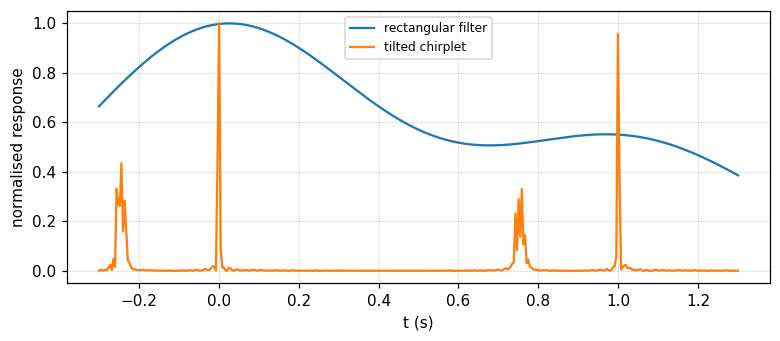

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.plot(ts_scan, np.abs(resp_rect)/np.max(np.abs(resp_rect)), label=("rectangular filter"))
ax.plot(ts_scan, np.abs(resp_ch)/np.max(np.abs(resp_ch)), label=("tilted chirplet"))
ax.set_xlabel("t (s)"); ax.set_ylabel(("normalised response")); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
Wavelet energy unchanged 0.3536; cross-correlation and convolution differ by 1e-16; threshold coding normalised error 0.8255; resolution: 0.5 (untilted) against 0.957 (chirplet).

## 5. The Wigner distribution: standard examples and projections
🎯 **What question does this method answer?** Does the numerical Wigner distribution of a chirp, a cosine wave and two impulses match the book's standard formulas, and does the frequency projection return exactly $|f(t)|^2$?

In [8]:
def Wig(fun, t, f, tau_max, N=60000):
    tau = np.linspace(-tau_max, tau_max, N)
    integrand = fun(t + tau/2)*np.conj(fun(t - tau/2))*np.exp(-1j*2*np.pi*f*tau)
    return trap(integrand, tau).real
# chirp
f0c, betac, t0c = 100.0, 50.0, 0.3
def fchirp(t): return np.exp(1j*2*np.pi*(0.5*betac*t**2 + f0c*t))
fs_scan = np.linspace(90, 140, 101)
vals = np.array([Wig(fchirp, t0c, fr, tau_max=3.0, N=30000) for fr in fs_scan])
ipk = np.argmax(vals)
report("wig_chirp_peak", fs_scan[ipk], ".1f"); report("wig_chirp_cf", f0c + betac*t0c, ".1f")
assert abs(fs_scan[ipk] - (f0c + betac*t0c)) < 5
# cosine wave
f0w = 50.0
def fcos(t): return np.cos(2*np.pi*f0w*t)
t1 = 0.005  # 4 f0 t1 = pi
v0 = Wig(fcos, 0.0, 0.0, tau_max=0.15, N=30000)
v_pi = Wig(fcos, t1, 0.0, tau_max=0.15, N=30000)
v_2pi = Wig(fcos, 2*t1, 0.0, tau_max=0.15, N=30000)
report("wig_cos_0", v0/v0, ".1f"); report("wig_cos_pi", v_pi/v0, ".2f"); report("wig_cos_2pi", v_2pi/v0, ".2f")
assert v_pi/v0 < 0 and v_2pi/v0 > 0
# two impulses: cos(8π f) at t=3
eps2 = 0.02
def f2imp(t): return np.exp(-(t - 1)**2/(2*eps2**2)) + np.exp(-(t - 5)**2/(2*eps2**2))
w0_ = Wig(f2imp, 3.0, 0.0, tau_max=4.5, N=400000)
w1_ = Wig(f2imp, 3.0, 0.125, tau_max=4.5, N=400000)
w2_ = Wig(f2imp, 3.0, 0.25, tau_max=4.5, N=400000)
report("wig_two_0", w0_/w0_, ".1f"); report("wig_two_1", w1_/w0_, ".2f"); report("wig_two_2", w2_/w0_, ".2f")
assert w1_/w0_ < 0 and w2_/w0_ > 0
# frequency projection
def fmix(t): return np.exp(-((t - 0.3)/0.1)**2/2)*np.cos(16*np.pi*t) + 0.5*np.exp(-((t - 0.7)/0.05)**2/2)
tproj = 0.32
proj = integrate.quad(lambda fr: Wig(fmix, tproj, fr, tau_max=1.5, N=6000), -60, 60, limit=200)[0]
target = fmix(tproj)**2
report("wig_proj", max(abs(proj - target), 1e-16), ".0e")
assert abs(proj - target) < 1e-3

▸ wig_chirp_peak = 115
▸ wig_chirp_cf = 115
▸ wig_cos_0 = 1
▸ wig_cos_pi = -1
▸ wig_cos_2pi = 1
▸ wig_two_0 = 1
▸ wig_two_1 = -1
▸ wig_two_2 = 1


▸ wig_proj = 9e-16


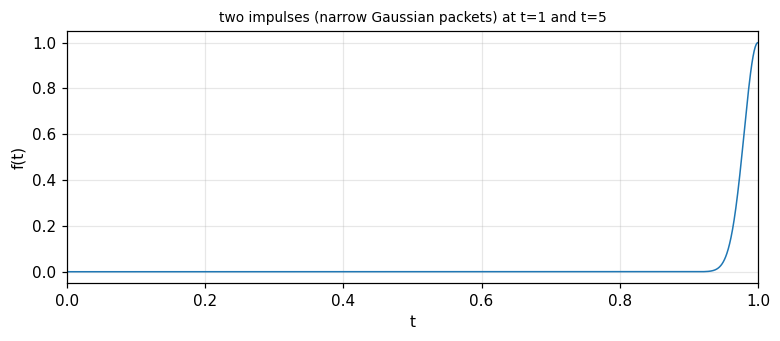

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
ts_ = np.linspace(0, 1, 4001)
ax.plot(ts_, f2imp(ts_), lw=1.0)
ax.set_xlabel("t"); ax.set_ylabel("f(t)"); ax.set_title(("two impulses (narrow Gaussian packets) at t=1 and t=5"), fontsize=9)
ax.set_xlim(0, 1); plt.tight_layout(); plt.show()

#### 📤 Real output
Chirp: numerical peak 115 Hz against the formula 115 Hz; cosine wave: 1, -1, 1; two impulses: 1, -1, 1; the frequency projection deviates 9e-16.